In [48]:
import toy_models
import linear_models
import engine
import data
import torch
import matplotlib.pyplot as plt
import numpy as np

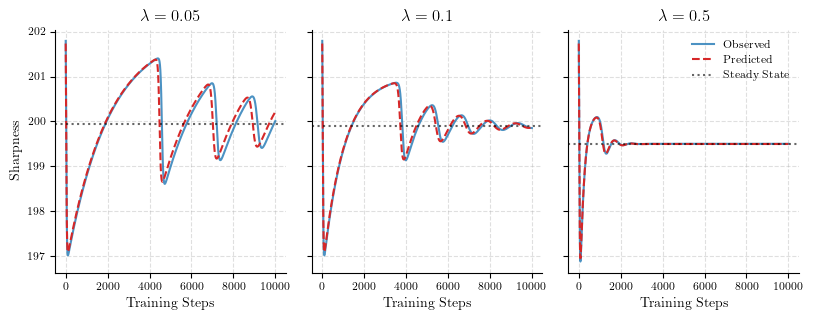

In [2]:
# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    # Use LaTeX for text rendering (requires a local LaTeX installation)
    # If this throws an error, set to False and rely on the font.family fallback
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 10,           # Matches standard NeurIPS text
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (8.25, 3.3), # 5.5 inch width fits perfectly in NeurIPS
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

# 2. Generate Synthetic Data (e.g., parameter decay dynamics)

x0=2.0
y0=1
z0=0
lr=0.01
alpha=0.1
beta=3
n_steps=10000
lambdas = [0.05, 0.1, 0.5]

# 3. Create 1x3 Subplots
fig, axes = plt.subplots(1, 3, sharey=True)

# Colors: using a colorblind-friendly approach
color_obs = '#1f77b4'  # Muted Blue
color_pred = '#d62728' # Brick Red
color_steady = 'black'

for i, (ax, lam) in enumerate(zip(axes, lambdas)):
    # Mathematical model: exponential decay to c
    data = toy_models.gd_run(
        x0=x0,
        y0=y0,
        z0=z0,
        lr=0.01,
        wd=lam,
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
    )
    
    predicted = toy_models.predict_dynamics(
        x0=x0,
        y0=y0,
        lr=lr,
        wd=lam,
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
    )

    # Plotting
    ax.plot(np.arange(n_steps+1), data["S"], linestyle='-', color=color_obs, alpha=0.8, label='Observed')
    ax.plot(np.arange(n_steps+1), predicted["S_pred"], linestyle='--', color=color_pred, label='Predicted')
    ax.axhline(200-lam, linestyle=':', color=color_steady, alpha=0.6, label='Steady State')

    # Formatting each axis
    ax.set_title(rf'$\lambda = {lam}$')
    ax.set_xlabel('Training Steps')
    
    # Only add y-label to the leftmost plot to save space
    if i == 0:
        ax.set_ylabel('Sharpness')
    if i == 2:
        ax.legend(loc='upper right', frameon=False) 
        
    # Clean up grid and spines
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Export safely with tight bounding box
plt.tight_layout()
plt.savefig('model_accuracy.pdf', format='pdf', bbox_inches='tight')
plt.show()

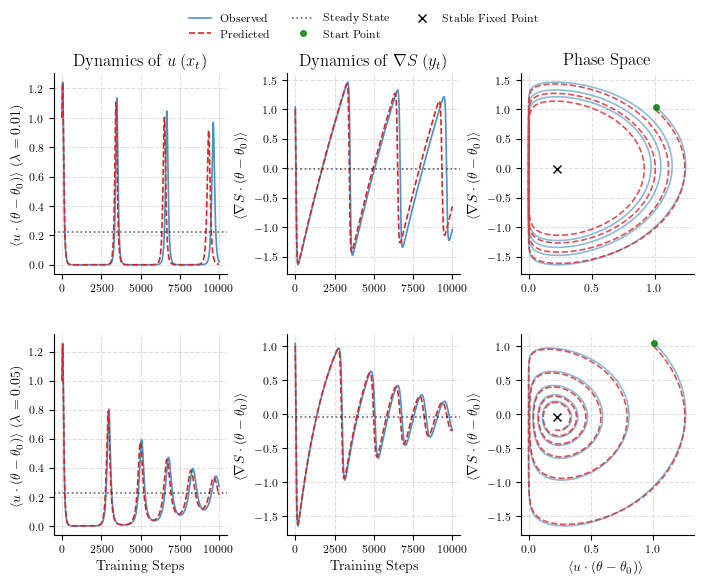

In [ ]:
# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 10,           
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (8.25, 6), # 5.5 width for NeurIPS, 4.0 height for 2 rows
    "lines.linewidth": 1.2,       # Slightly thinner lines for denser subplots
    "axes.linewidth": 0.8,
})
x0=1
y0=0.5
z0=0
lr=0.01
alpha=0.1
beta=4
n_steps=10000
lambdas = [0.01, 0.05]

# Create 2x3 Subplots
fig, axes = plt.subplots(2, 3)
fig.subplots_adjust(wspace=0.35, hspace=0.3) # Give columns room to breathe

# Color scheme
color_obs = '#1f77b4'  
color_pred = '#d62728' 
color_steady = 'black'

for row, lam in enumerate(lambdas):
    # --- FETCH DATA ---
    # Replace these function calls with your actual toy_models calls
    data = toy_models.gd_run(
        x0=x0, y0=y0, z0=z0, lr=0.01, wd=lam, 
        alpha=alpha, beta=beta, n_steps=n_steps
    )
    predicted = toy_models.predict_dynamics(
        x0=x0, y0=y0, lr=0.01, wd=lam, 
        alpha=alpha, beta=beta, n_steps=n_steps
    )

    # --- PROCESS VARIABLES ---
    time_steps = np.arange(n_steps + 1)
    
    # Column 1 Data (u)
    u_obs = np.abs(np.vecdot(data["u"], data["xyz"], axis=1))
    u_pred = np.abs(predicted["x_pred"])
    u_steady = predicted["X_resting"]
    
    # Column 2 Data (\nabla S)
    grad_s_obs = np.vecdot(data["grad_S"], data["xyz"], axis=1)
    grad_s_pred = predicted["S_pred"] - 2/lr
    grad_s_steady = -lam

    # --- PLOTTING ---
    
    # Col 1: u evolution
    ax_u = axes[row, 0]
    ax_u.plot(time_steps, u_obs, '-', color=color_obs, alpha=0.8, label='Observed')
    ax_u.plot(time_steps, u_pred, '--', color=color_pred, label='Predicted')
    ax_u.axhline(u_steady, color=color_steady, linestyle=':', alpha=0.6, label='Steady State')
    
    # Col 2: \nabla S evolution
    ax_s = axes[row, 1]
    ax_s.plot(time_steps, grad_s_obs, '-', color=color_obs, alpha=0.8)
    ax_s.plot(time_steps, grad_s_pred, '--', color=color_pred)
    ax_s.axhline(grad_s_steady, color=color_steady, linestyle=':', alpha=0.6)

    # Col 3: Phase Space (u vs \nabla S)
    ax_p = axes[row, 2]
    # Trajectories
    ax_p.plot(u_obs, grad_s_obs, '-', color=color_obs, alpha=0.5)
    ax_p.plot(u_pred, grad_s_pred, '--', color=color_pred, alpha=0.8)
    
    # Markers for Phase Space (Start and End)
    ax_p.plot(u_obs[0], grad_s_obs[0], 'go', markersize=4, label='Start Point', alpha=0.8)
    ax_p.plot(u_steady, grad_s_steady, 'kx', markersize=6, label='Stable Fixed Point')

    # --- FORMATTING & CLEANUP ---
    
    # Add Y-labels only to the left-most columns
    ax_u.set_ylabel(rf'$\langle u \cdot (\theta-\theta_0)\rangle$ ($\lambda={lam}$)')
    ax_s.set_ylabel(rf'$\langle \nabla S \cdot (\theta-\theta_0)\rangle$')
    ax_p.set_ylabel(rf'$\langle \nabla S \cdot (\theta-\theta_0)\rangle$')

    # Add titles only to the top row
    if row == 0:
        ax_u.set_title(r'Dynamics of $u\;(x_t)$')
        ax_s.set_title(r'Dynamics of $\nabla S\;(y_t)$')
        ax_p.set_title(r'Phase Space')
        
    # Add X-labels only to the bottom row
    if row == len(lambdas) - 1:
        ax_u.set_xlabel('Training Steps')
        ax_s.set_xlabel('Training Steps')
        ax_p.set_xlabel(rf'$\langle u \cdot (\theta-\theta_0)\rangle$')
        # ax_p.set_ylabel(r'$|\nabla S|$', labelpad=0) # labelpad prevents overlap

    # Grid and spines for all axes
    for ax in [ax_u, ax_s, ax_p]:
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 4. Legend Handling
# Place a single shared legend at the top of the entire figure to save space
# 4. Legend Handling
# Grab handles from the first column (time series lines)
handles_time, labels_time = axes[0, 0].get_legend_handles_labels()

# Grab handles from the third column (phase space markers)
handles_phase, labels_phase = axes[0, 2].get_legend_handles_labels()

# Combine the handles and labels
handles = handles_time + handles_phase
labels = labels_time + labels_phase

# Place the unified legend at the top. 
# Because we now have 5 items, ncol=3 will create two rows. 
# We bump bbox_to_anchor up slightly to (0.5, 1.08) to give those two rows enough room.
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.92), ncol=3, frameon=False)
# Lowered legend placement
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False)
# 5. Export
plt.savefig('model_accuracy_2x3.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [42]:
X,y = linear_models.generate_ill_conditioned_data(num_samples=1000, input_dim=4)
# model = linear_models.LinearModel(input_dim=4, d=24, depth=4)
# model2 = linear_models.LinearModel(input_dim=4, d=24, depth=4)
mlp = linear_models.FullReLU(input_dim=4, d=64, depth=1)

In [ ]:
run = engine.advanced_gd_run(
    model=mlp,
    X=X,
    y=y,
    lr=0.005,
    wd=0,
    num_epochs=250,
    log_every_n=1
)

Using device: cpu

Epoch [10/250], Loss: 28.0475
Epoch [20/250], Loss: 26.8915
Epoch [30/250], Loss: 26.4584
Epoch [40/250], Loss: 26.1841
Epoch [50/250], Loss: 25.9821
Epoch [60/250], Loss: 25.8220
Epoch [70/250], Loss: 25.6875
Epoch [80/250], Loss: 25.5728
Epoch [90/250], Loss: 25.4792
Epoch [100/250], Loss: 25.3977
Epoch [110/250], Loss: 25.3260
Epoch [120/250], Loss: 25.2657
Epoch [130/250], Loss: 25.2131
Epoch [140/250], Loss: 25.1650
Epoch [150/250], Loss: 25.1207
Epoch [160/250], Loss: 25.0811
Epoch [170/250], Loss: 25.0462
Epoch [180/250], Loss: 25.0136
Epoch [190/250], Loss: 24.9830
Epoch [200/250], Loss: 24.9518
Epoch [210/250], Loss: 24.9218
Epoch [220/250], Loss: 24.8930
Epoch [230/250], Loss: 24.8647
Epoch [240/250], Loss: 24.8378
Epoch [250/250], Loss: 24.8126

Training complete!


In [49]:
cifar_x, cifar_y = data.get_cifar10_subset(num_samples=5000)

100.0%
/home/kolic/Desktop/slt-experiments/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [60]:
mlp = linear_models.LinearModel(input_dim=3072, d=128, depth=1)
run = engine.advanced_gd_run(
    model=mlp,
    X=cifar_x,
    y=cifar_y,
    lr=0.01,
    wd=0,
    num_epochs=100,
    log_every_n=10
)

Using device: cpu



/home/kolic/Desktop/slt-experiments/.venv/lib/python3.13/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([5000, 10])) that is different to the input size (torch.Size([5000, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [10/100], Loss: 0.0959
Epoch [20/100], Loss: 0.0939
Epoch [30/100], Loss: 0.0929
Epoch [40/100], Loss: 0.0924
Epoch [50/100], Loss: 0.0920
Epoch [60/100], Loss: 0.0917
Epoch [70/100], Loss: 0.0916
Epoch [80/100], Loss: 0.0914
Epoch [90/100], Loss: 0.0913
Epoch [100/100], Loss: 0.0912

Training complete!


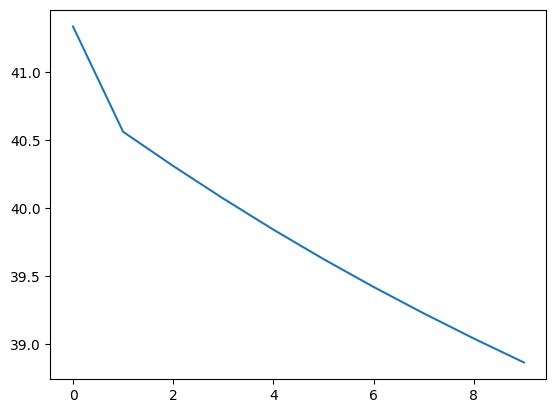

In [62]:
plt.plot(run["sharpness"])